# Lotka–Volterra Competition Model

## Overview
The Lotka–Volterra competition model is a classical mathematical model in ecology that describes the population dynamics of two species competing for the same limited resources. It provides insight into coexistence, competitive exclusion, and the effect of competition coefficients on population stability.

---

## Model

The system is described by the following differential equations:

$$
\frac{dx}{dt} = r_1 x \left(1 - \frac{x + \alpha y}{K_1}\right)
$$

$$
\frac{dy}{dt} = r_2 y \left(1 - \frac{y + \beta x}{K_2}\right)
$$

Where:

- $x, y$ : Population sizes of species 1 and 2  
- $r_1, r_2$ : Intrinsic growth rates  
- $K_1, K_2$ : Carrying capacities  
- $\alpha, \beta$ : Competition coefficients (effect of one species on the other)

The model can exhibit **coexistence**, **competitive exclusion**, or **bistability** depending on the parameter values.

---

## Simulation Method

Numerical integration is performed using Python's `scipy.integrate.odeint`:

```python
from scipy.integrate import odeint
from model import lotka_volterra
import numpy as np

t = np.linspace(0, 50, 500)
initial = [10, 10]
params = (1, 1, 100, 100, 0.5, 0.5)

solution = odeint(lotka_volterra, initial, t, args=params)
x = solution[:,0]
y = solution[:,1]

## Lotka–Volterra Competition Model
# Defines the classical two-species competition model.


In [39]:
import numpy as np

def lotka_volterra(pop, t, r1, r2, K1, K2, alpha, beta):
    """
    Lotka-Volterra competition model
    pop: [x,y] population sizes
    """
    x, y = pop
    dx = r1 * x * (1 - (x + alpha * y) / K1)
    dy = r2 * y * (1 - (y + beta * x) / K2)
    return [dx, dy]

## Time Series Simulation
# Simulates population dynamics of two competing species over time
# and plots the resulting time series.


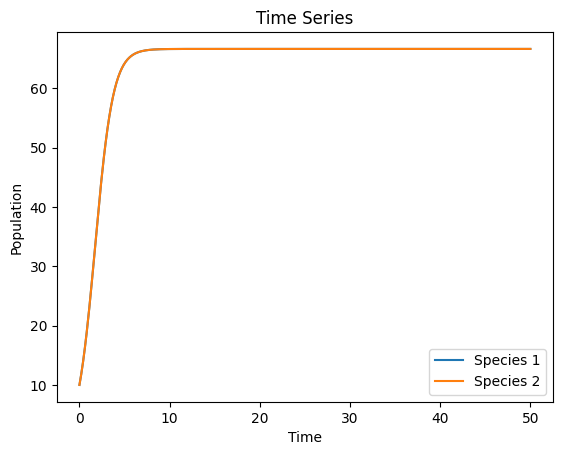

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


# Parameters
r1, r2 = 1, 1
K1, K2 = 100, 100
alpha, beta = 0.5, 0.5

# Time
t = np.linspace(0, 50, 500)

# Initial population
initial = [10, 10]

sol = odeint(lotka_volterra, initial, t, args=(r1, r2, K1, K2, alpha, beta))

x = sol[:,0]
y = sol[:,1]

plt.plot(t, x, label="Species 1")
plt.plot(t, y, label="Species 2")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Time Series")
plt.legend()
plt.show()

### Discussion

The time series shows that both species populations increase initially
and eventually approach a stable equilibrium.

Because the competition coefficients (α=0.5, β=0.5) are moderate,
neither species completely excludes the other.
Instead, the system converges to a coexistence equilibrium.

## Analytical Tools
# Provides functions for equilibrium and stability analysis of the model.

In [27]:
import numpy as np

def coexistence_equilibrium(K1, K2, alpha, beta):
    """
    Compute coexistence equilibrium point
    """
    x = (K1 - alpha*K2)/(1 - alpha*beta)
    y = (K2 - beta*K1)/(1 - alpha*beta)
    return x, y

def jacobian(x, y, r1, r2, K1, K2, alpha, beta):
    """
    Compute Jacobian matrix at (x,y)
    """
    j11 = r1 * (1 - (2*x + alpha*y)/K1)
    j12 = -r1 * alpha * x / K1
    j21 = -r2 * beta * y / K2
    j22 = r2 * (1 - (2*y + beta*x)/K2)
    return np.array([[j11, j12],
                     [j21, j22]])

## Phase Space Plot
# Utility function to visualize phase space trajectories.


In [29]:
import matplotlib.pyplot as plt

def plot_phase(x, y):
    """
    Plot phase space
    """
    plt.plot(x, y)
    plt.xlabel("Species 1")
    plt.ylabel("Species 2")
    plt.title("Phase Space")
    plt.show()

## Phase Space Simulation
# Simulates multiple initial conditions and plots trajectories in phase space.


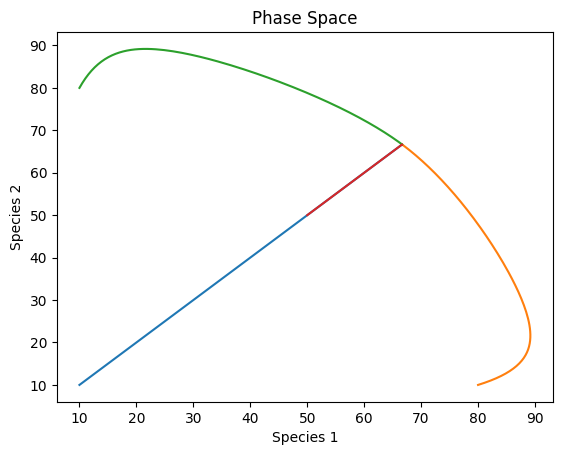

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

t = np.linspace(0, 50, 500)

initial_conditions = [
    [10, 10],
    [80, 10],
    [10, 80],
    [50, 50]
]

for ic in initial_conditions:
    sol = odeint(lotka_volterra, ic, t, args=(1, 1, 100, 100, 0.5, 0.5))
    plt.plot(sol[:,0], sol[:,1])

plt.xlabel("Species 1")
plt.ylabel("Species 2")
plt.title("Phase Space")
plt.show()

### Discussion

The phase trajectories from different initial conditions converge
toward the same equilibrium point.

This indicates that the equilibrium is globally stable
for the chosen parameter set.

## Bifurcation Analysis
# Plots equilibrium population of species 1 as alpha varies.


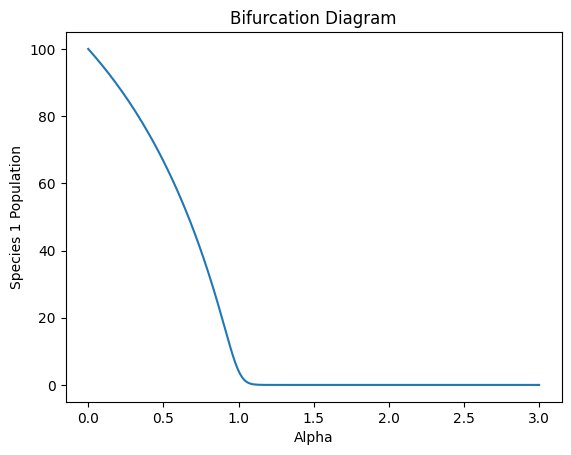

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

alphas = np.linspace(0, 3, 200)
final_x = []

t = np.linspace(0, 50, 500)

for a in alphas:
    sol = odeint(lotka_volterra, [10, 10], t, args=(1, 1, 100, 100, a, 0.5))
    final_x.append(sol[-1, 0])

plt.plot(alphas, final_x)
plt.xlabel("Alpha")
plt.ylabel("Species 1 Population")
plt.title("Bifurcation Diagram")
plt.show()

### Discussion

The bifurcation diagram shows how the final population
of species 1 depends on the competition coefficient α.

As α increases, species 2 exerts stronger competitive pressure,
which eventually drives species 1 toward extinction.

## Competition Outcome Map
# Scans alpha-beta parameter space and classifies final outcomes.


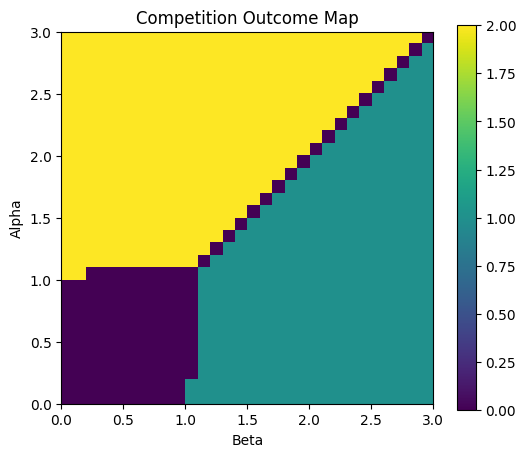

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def lotka_volterra(pop, t, r1, r2, K1, K2, alpha, beta):
    x, y = pop
    dx = r1 * x * (1 - (x + alpha*y)/K1)
    dy = r2 * y * (1 - (y + beta*x)/K2)
    return [dx, dy]

alphas = np.linspace(0,3,30)
betas = np.linspace(0,3,30)

grid = np.zeros((30,30))
t = np.linspace(0,50,300)

for i,a in enumerate(alphas):
    for j,b in enumerate(betas):
        sol = odeint(lotka_volterra,[10,10],t,args=(1,1,100,100,a,b))
        x,y = sol[-1]

        if x>1 and y>1:
            grid[i,j]=0
        elif x>y:
            grid[i,j]=1
        else:
            grid[i,j]=2

plt.figure(figsize=(6,5))
plt.imshow(grid,origin="lower",extent=[0,3,0,3])
plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Competition Outcome Map")
plt.colorbar()
plt.show()

### Discussion

The competition outcome map reveals regions of coexistence
and competitive exclusion in the parameter space (α, β).

When both α and β are small, coexistence is possible.
Larger values typically lead to dominance of one species.

## Vector Field Visualization
# Plots quiver plot of population change directions in the phase space.

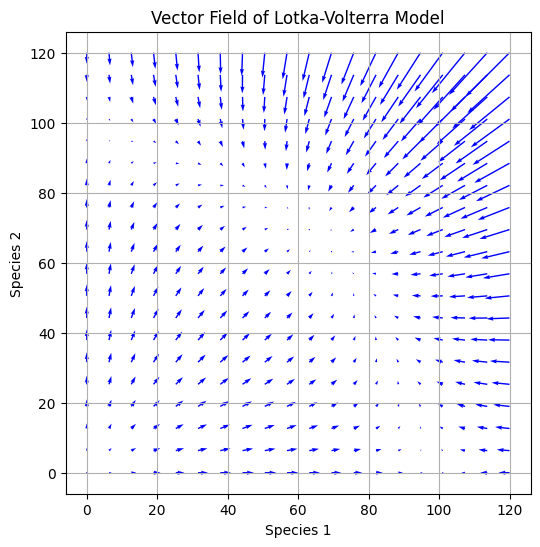

In [34]:
import numpy as np
import matplotlib.pyplot as plt

r1, r2 = 1, 1
K1, K2 = 100, 100
alpha, beta = 0.5, 0.5

x_vals = np.linspace(0, 120, 20)
y_vals = np.linspace(0, 120, 20)
X, Y = np.meshgrid(x_vals, y_vals)

U = r1*X*(1-(X + alpha*Y)/K1)
V = r2*Y*(1-(Y + beta*X)/K2)

plt.figure(figsize=(6,6))
plt.quiver(X, Y, U, V, color='blue')
plt.xlabel("Species 1")
plt.ylabel("Species 2")
plt.title("Vector Field of Lotka-Volterra Model")
plt.grid(True)
plt.show()

### Discussion

The vector field illustrates the direction of population change
for different combinations of species populations.

Arrows indicate the local growth or decline tendencies of each species.
Trajectories of the system follow these directions and typically move
toward equilibrium points.

This visualization helps identify stable regions and understand the
overall structure of the dynamical system in phase space.

## Stochastic Lotka–Volterra Model
# Introduces noise to simulate stochastic population dynamics.

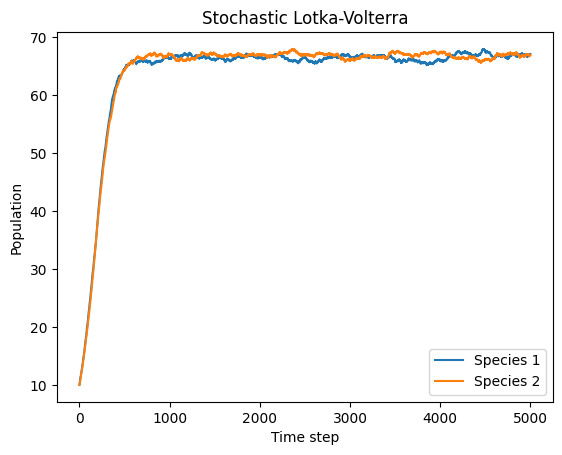

In [35]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01
steps = 5000

x = np.zeros(steps)
y = np.zeros(steps)
x[0] = 10
y[0] = 10
sigma = 0.5

for i in range(steps-1):
    dx = x[i]*(1-(x[i]+0.5*y[i])/100)
    dy = y[i]*(1-(y[i]+0.5*x[i])/100)
    x[i+1] = x[i] + dx*dt + sigma*np.random.randn()*np.sqrt(dt)
    y[i+1] = y[i] + dy*dt + sigma*np.random.randn()*np.sqrt(dt)

plt.plot(x,label="Species 1")
plt.plot(y,label="Species 2")
plt.xlabel("Time step")
plt.ylabel("Population")
plt.title("Stochastic Lotka-Volterra")
plt.legend()
plt.show()

### Discussion

In this stochastic version of the Lotka–Volterra model,
random fluctuations are added to the population dynamics.

These fluctuations can represent environmental variability,
measurement noise, or random birth–death events.

Compared with the deterministic model, the trajectories
no longer converge smoothly to equilibrium.
Instead, populations fluctuate around the stable state,
demonstrating how noise can influence ecological dynamics.

## Three-Species Competition Model
# Extends Lotka–Volterra to three competing species.

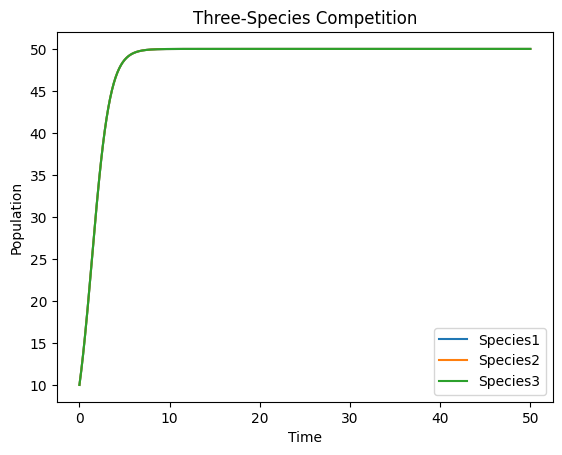

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def model(pop, t):
    x, y, z = pop
    dx = x*(1-(x+0.5*y+0.5*z)/100)
    dy = y*(1-(y+0.5*x+0.5*z)/100)
    dz = z*(1-(z+0.5*x+0.5*y)/100)
    return [dx, dy, dz]

t = np.linspace(0,50,500)
sol = odeint(model, [10,10,10], t)
plt.plot(t, sol)
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Three-Species Competition")
plt.legend(["Species1","Species2","Species3"])
plt.show()

### Discussion

The three-species extension illustrates how competitive interactions
become more complex as additional species are introduced.

Unlike the two-species system, higher-dimensional dynamics may produce
more complicated trajectories and potential instability.

Such models are useful for exploring biodiversity,
resource competition, and ecological community structure.

## Nullcline Analysis

In [41]:
x_eq, y_eq = coexistence_equilibrium(100,100,0.5,0.5)
J = jacobian(x_eq, y_eq, 1,1,100,100,0.5,0.5)

eigvals = np.linalg.eigvals(J)

print("Equilibrium:", x_eq, y_eq)
print("Eigenvalues:", eigvals)

Equilibrium: 66.66666666666667 66.66666666666667
Eigenvalues: [-0.33333333 -1.        ]


### Discussion
The eigenvalues of the Jacobian determine the stability of the equilibrium.
Negative real parts indicate a stable equilibrium.

## Tools Used

- Python
- NumPy
- SciPy
- Matplotlib
- Jupyter Notebook

## Conclusion

This notebook explored the Lotka–Volterra competition model using
numerical simulation and dynamical systems analysis.

Key findings include:

- Population trajectories converge to equilibrium for moderate competition coefficients
- Phase space trajectories reveal stable coexistence
- Bifurcation analysis shows how competition strength alters system outcomes
- Stochastic extensions demonstrate the role of environmental fluctuations
- Higher-dimensional models introduce more complex ecological dynamics

These results demonstrate how classical ecological models
can be analyzed using numerical simulations and dynamical systems theory.

## References

1. Lotka, A. J. (1925). *Elements of Physical Biology*. Williams & Wilkins.

2. Volterra, V. (1926). Fluctuations in the abundance of a species considered mathematically. *Nature*, 118, 558–560.

3. Murray, J. D. (2002). *Mathematical Biology I: An Introduction*. Springer.

4. Edelstein-Keshet, L. (2005). *Mathematical Models in Biology*. SIAM.

5. Strogatz, S. H. (2015). *Nonlinear Dynamics and Chaos*. Westview Press.